In [49]:
import pandas as pd
import numpy as np

## 2. Load Data

Loading 8 of the 9 Olist CSVs (all except `geolocation.csv`, which isn't needed for these questions).

In [50]:
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_order_items = pd.read_csv('olist_order_items_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_sellers = pd.read_csv('olist_sellers_dataset.csv')
df_order_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_category_name = pd.read_csv('product_category_name_translation.csv')

In [51]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## 3. Missing Value Check

In [52]:
print('orders:\n', df_orders.isnull().sum())
print('\norder_items:\n', df_order_items.isnull().sum())
print('\nproducts:\n', df_products.isnull().sum())

orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

order_items:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

products:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


## 4. Merge Into a Single Working Table

In [53]:
df_payments_agg = df_order_payments.groupby('order_id', as_index=False)['payment_value'].sum()

df = (
    df_orders
    .merge(df_order_items, how='left', on='order_id')
    .merge(df_products, how='left', on='product_id')
    .merge(df_customers, how='left', on='customer_id')
    .merge(df_order_reviews, how='left', on='order_id')
    .merge(df_payments_agg, how='left', on='order_id')
    .merge(df_category_name, how='left', on='product_category_name')
    .merge(df_sellers, how='left', on='seller_id')
)

# Check revenue before vs. after merging should match at the order level.
# If these two numbers differ, a merge is still duplicating rows somewhere.
revenue_before = df_order_items['price'].sum()
revenue_after = df.drop_duplicates(subset=['order_id', 'order_item_id'])['price'].sum()
print(f'Revenue before merges: R${revenue_before:,.2f}')
print(f'Revenue after merges:  R${revenue_after:,.2f}')
print('Match!' if abs(revenue_before - revenue_after) < 1 else 'MISMATCH — a merge is duplicating rows, investigate before trusting any revenue chart')

Revenue before merges: R$13,591,643.70
Revenue after merges:  R$13,591,643.70
Match!


## 5. Post-Merge Missing Values

In [54]:
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   162
order_delivered_carrier_date       1980
order_delivered_customer_date      3253
order_estimated_delivery_date         0
order_item_id                       778
product_id                          778
seller_id                           778
shipping_limit_date                 778
price                               778
freight_value                       778
product_category_name              2390
product_name_lenght                2390
product_description_lenght         2390
product_photos_qty                 2390
product_weight_g                    796
product_length_cm                   796
product_height_cm                   796
product_width_cm                    796
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0


In [55]:
#Check for missing values
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   162
order_delivered_carrier_date       1980
order_delivered_customer_date      3253
order_estimated_delivery_date         0
order_item_id                       778
product_id                          778
seller_id                           778
shipping_limit_date                 778
price                               778
freight_value                       778
product_category_name              2390
product_name_lenght                2390
product_description_lenght         2390
product_photos_qty                 2390
product_weight_g                    796
product_length_cm                   796
product_height_cm                   796
product_width_cm                    796
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0


## 6. Cleaning

In [56]:
# Handle missing delivery dates 
df_delivery = df[df['order_delivered_customer_date'].notna()].copy()


In [57]:
df['order_status'].value_counts()

order_status
delivered      110840
shipped          1197
canceled          711
unavailable       612
invoiced          366
processing        358
created             5
approved            3
Name: count, dtype: int64

In [58]:
# Check for duplicate order IDs. These are expected — one order can have multiple line items —
# not true duplicates to drop. Confirmed by checking what differs between matching rows below.
print('Duplicated order_id rows:', df['order_id'].duplicated().sum())
df[df['order_id'].duplicated(keep=False)].sort_values('order_id').head()

Duplicated order_id rows: 14651


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_value,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
61835,0008288aa423d2a3f00fcb17cd7d8719,2355af7c75e7c98b43a87b2a7f210dc5,delivered,2018-02-13 22:10:21,2018-02-15 03:55:52,2018-02-20 18:23:28,2018-02-26 13:55:22,2018-03-06 00:00:00,2.0,368c6c730842d78016ad823897a372db,...,5.0,NaN,NaN,2018-02-27 00:00:00,2018-03-02 10:20:40,126.54,garden_tools,15025.0,sao jose do rio preto,SP
61834,0008288aa423d2a3f00fcb17cd7d8719,2355af7c75e7c98b43a87b2a7f210dc5,delivered,2018-02-13 22:10:21,2018-02-15 03:55:52,2018-02-20 18:23:28,2018-02-26 13:55:22,2018-03-06 00:00:00,1.0,368c6c730842d78016ad823897a372db,...,5.0,NaN,NaN,2018-02-27 00:00:00,2018-03-02 10:20:40,126.54,garden_tools,15025.0,sao jose do rio preto,SP
41557,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06 00:00:00,2.0,e95ee6822b66ac6058e2e4aff656071a,...,NaN,NaN,NaN,NaN,NaN,109.29,sports_leisure,18055.0,sorocaba,SP
41558,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06 00:00:00,3.0,e95ee6822b66ac6058e2e4aff656071a,...,NaN,NaN,NaN,NaN,NaN,109.29,sports_leisure,18055.0,sorocaba,SP
41556,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06 00:00:00,1.0,e95ee6822b66ac6058e2e4aff656071a,...,NaN,NaN,NaN,NaN,NaN,109.29,sports_leisure,18055.0,sorocaba,SP


In [59]:
#Handle review score
df_delivery.dropna(subset=['review_score'])
df_delivery = df[df['order_delivered_customer_date'].notna()]

In [60]:
#Check for data types
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
product_category_name             object
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city   

In [61]:
# Convert date columns to real datetimes — needed before any delivery-time subtraction works
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date',
             'review_creation_date', 'review_answer_timestamp']
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')
df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_item_id                           float64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              float64
product_photos_qty                      float64
product_weight_g                        float64
product_length_cm                       float64
product_height_cm                       

## 7. Visualization Setup

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## 8. Monthly Revenue Trend

**Finding:** revenue grows steadily from late 2016 through late 2017, then holds roughly flat through mid-2018 — a maturing, stabilizing business rather than one still in early hockey-stick growth.

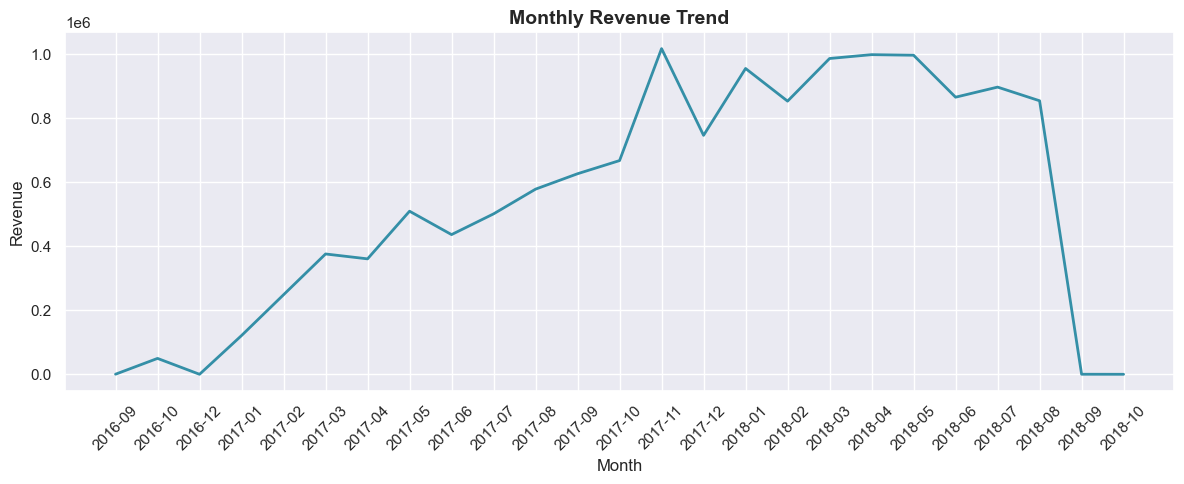

In [63]:

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = df.groupby('order_month')['price'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)
sns.set_theme()
plt.figure(figsize=(12,5))
rocket_colors = sns.color_palette('mako', n_colors=6) 
sns.lineplot(x= 'order_month',y= 'price', data = monthly_revenue, linewidth=2, markersize=7,markers='o',color=rocket_colors[3])
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

## 9. Category Performance: Revenue vs. Order Count

**Finding:** `bed_bath_table` has the highest order count but ranks lower in revenue, while `watches_gifts` ranks high in revenue with fewer orders — a volume-vs-value split worth treating as two different levers.

/var/folders/gx/59q_qxd95tlg2ypf0nz73x5c0000gn/T/ipykernel_65952/998912669.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


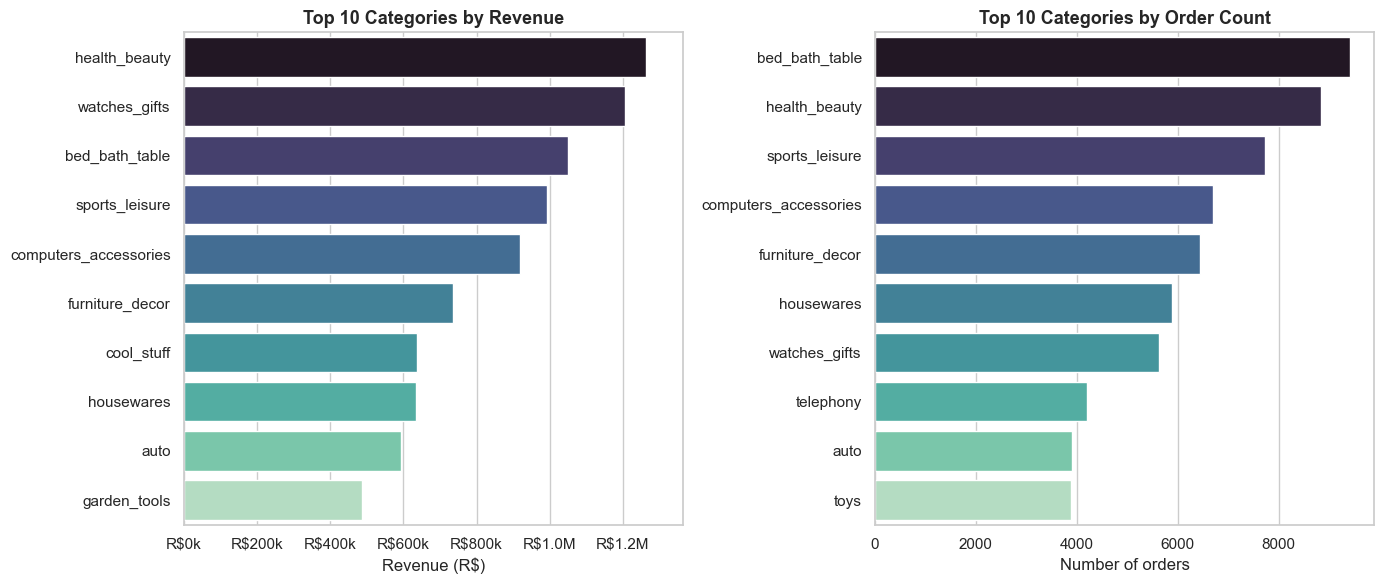

In [64]:
revenue_category = df.groupby('product_category_name_english')['price'].sum().reset_index()
order_count_category = df.groupby('product_category_name_english')['order_id'].nunique().reset_index()

top_revenue = revenue_category.sort_values('price', ascending=False).head(10)
top_orders = order_count_category.sort_values('order_id', ascending=False).head(10)

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
palette = sns.color_palette('mako', n_colors=10) 

sns.barplot(x='price', y='product_category_name_english', data=top_revenue,
hue='product_category_name_english', palette=palette, legend=False, ax=axes[0])
axes[0].set_title('Top 10 Categories by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (R$)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R${x/1e6:.1f}M' if x >= 1e6 else f'R${x/1e3:.0f}k'))
axes[0].margins(x=0.08)
sns.barplot(x='order_id', y='product_category_name_english', data=top_orders,
hue='product_category_name_english', palette=palette, legend=False, ax=axes[1])
axes[1].set_title('Top 10 Categories by Order Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of orders')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 10. Delivery Time vs. Review Score

**Finding:** average review score drops steadily as delivery time increases (4.39 for 0-3 days down to 3.6 for 15+ days). The boxplot shows the 15+ day bucket isn't just lower on average — it's far more spread out, with a much heavier concentration of 1-2 star outliers.

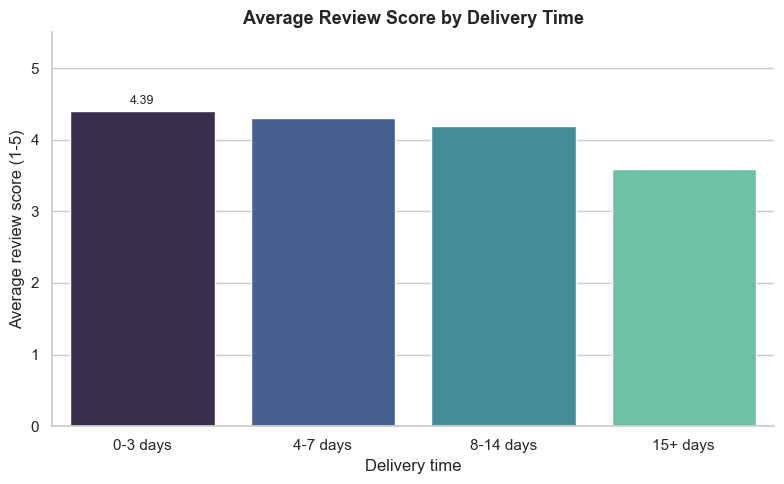

In [65]:
# Filter to delivered orders with a review score 
df_delivery = df[df['order_delivered_customer_date'].notna()].dropna(subset=['review_score']).copy()

# Delivery time in whole days
df_delivery['delivery_days'] = (df_delivery['order_delivered_customer_date']- df_delivery['order_purchase_timestamp']).dt.days

# Bucket into ranges
bins = [0, 3, 7, 14, df_delivery['delivery_days'].max() + 1]
labels = ['0-3 days', '4-7 days', '8-14 days', '15+ days']
df_delivery['delivery_bucket'] = pd.cut(df_delivery['delivery_days'], bins=bins, labels=labels, right=True)

avg_score_by_bucket = df_delivery.groupby('delivery_bucket', observed=True)['review_score'].mean().reset_index()

sns.set_theme(style='whitegrid')
mako_colors = sns.color_palette('mako', n_colors=4)
plt.figure(figsize=(8, 5))
bars = sns.barplot(x='delivery_bucket', y='review_score', data=avg_score_by_bucket,
hue='delivery_bucket', palette=mako_colors, legend=False)
plt.title('Average Review Score by Delivery Time', fontsize=13, fontweight='bold')
plt.xlabel('Delivery time')
plt.ylabel('Average review score (1-5)')
plt.ylim(0, 5.5)
bars.bar_label(bars.containers[0], fmt='%.2f', padding=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


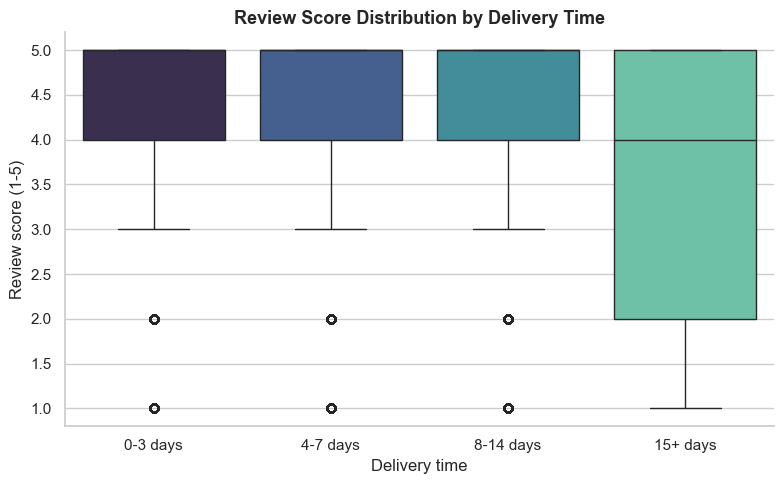

In [66]:
#boxplot review score by delivery time
plt.figure(figsize=(8, 5))
sns.boxplot(x='delivery_bucket', y='review_score', data=df_delivery,
hue='delivery_bucket', palette=mako_colors, legend=False)
plt.title('Review Score Distribution by Delivery Time', fontsize=13, fontweight='bold')
plt.xlabel('Delivery time')
plt.ylabel('Review score (1-5)')
sns.despine()
plt.tight_layout()
plt.show()

## 11. Regional Coverage: Orders per Local Seller

**Finding:** a handful of states are dramatically underserved relative to demand, led by PA at nearly 1,000 orders per local seller — more than 30% higher than the next-highest state.

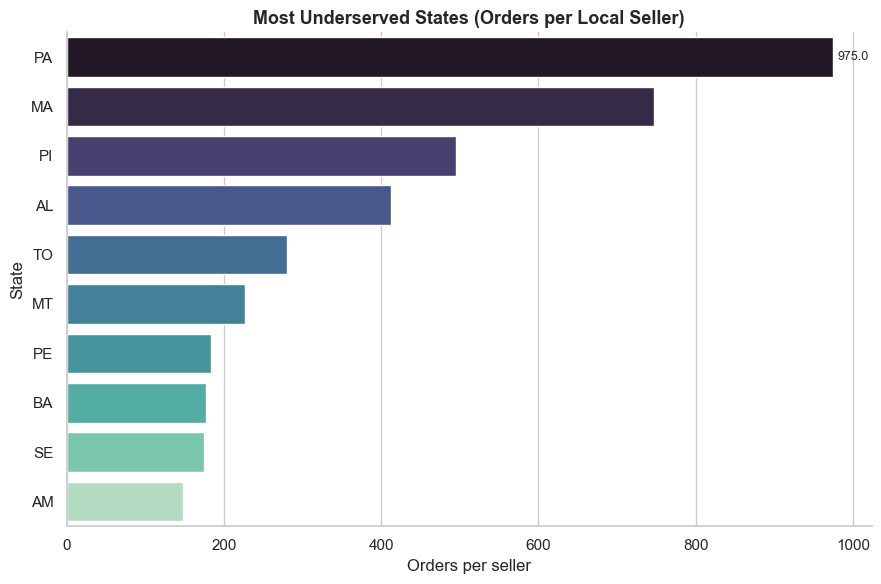

In [67]:
# Demand: orders per customer state (nunique, not count — avoids over-counting multi-item orders)
demand = df.groupby('customer_state')['order_id'].nunique().reset_index(name='order_count')

# Supply: distinct sellers per seller state
supply = df.groupby('seller_state')['seller_id'].nunique().reset_index(name='seller_count')
supply = supply.rename(columns={'seller_state': 'customer_state'}) 

# Filter out states with zero local sellers
region_balance = demand.merge(supply, on='customer_state', how='left')
region_balance['seller_count'] = region_balance['seller_count'].fillna(0)  

region_balance['orders_per_seller'] = region_balance.apply(
lambda row: row['order_count'] / row['seller_count'] if row['seller_count'] > 0 else float(row['order_count']),
axis=1)

top_underserved = region_balance.sort_values('orders_per_seller', ascending=False).head(10)

sns.set_theme(style='whitegrid')
mako_colors = sns.color_palette('mako', n_colors=10)
plt.figure(figsize=(9, 6))
bars = sns.barplot(x='orders_per_seller', y='customer_state', data=top_underserved,
hue='customer_state', palette=mako_colors, legend=False)
plt.title('Most Underserved States (Orders per Local Seller)', fontsize=13, fontweight='bold')
plt.xlabel('Orders per seller')
plt.ylabel('State')
bars.bar_label(bars.containers[0], fmt='%.1f', padding=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()